# ex03) 여러 가지 조합을 통한 다중분류 실습 (Fashion-MNIST)

> **한 줄 요약** : 활성화 함수 + 최적화 함수 **조합을 바꿔가며 성능을 비교**하는 것이 딥러닝 튜닝의 기본.

## 오늘의 흐름
| 단계 | 내용 |
|---|---|
| 1 | 최적화 함수(Optimizer) 종류 정리 - SGD / Momentum / Adagrad / Adam |
| 2 | Fashion-MNIST 데이터 불러오기 & 탐색 |
| 3 | 원핫인코딩 |
| 4 | 조합별 신경망 설계 및 학습 |
| 5 | 결과 시각화 및 비교 |

## 꼭 기억할 키워드
`Optimizer` `SGD` `Momentum` `Adagrad` `Adam` `Flatten` `softmax` `원핫인코딩` `baseline 비교`


# 1. 실습 목표

여러 가지 **활성화 함수(activation)** 와 **최적화 함수(optimizer)** 를 조합해서
가장 성능이 좋은 조합을 찾아내는 실습

- 지금까지 배운 `sigmoid` 외에 다른 활성화 함수도 사용해보기 (`tanh`, `relu` ...)
- 오차를 잘 줄일 수 있도록 **학습 방법을 설정하는 `optimizer`** 와 **`loss` 함수** 설정하기

> 딥러닝에는 "이게 정답"인 조합이 없다. **데이터마다 다르므로 직접 비교해봐야 한다.**


## 2. 최적화 함수 (Optimizer)

- 오차를 확인하여 **어떻게 하면 오차를 줄일 수 있는지** 분석해 학습 방법을 설정하는 함수
- 손실함수의 **기울기(미분값)** 를 구해, 오차가 낮아지는 방향으로 w를 이동시켜 최적값을 찾는다

> 산에서 내려올 때 "어느 방향으로, 얼마나 큰 보폭으로" 내려갈지 정하는 전략이라고 생각하면 쉽다.
> - **방향**을 개선한 것 → Momentum
> - **보폭(학습률)** 을 개선한 것 → Adagrad
> - **둘 다** 개선한 것 → Adam


### 2-1. SGD (확률적 경사하강법, Stochastic Gradient Descent)

- 오차를 줄여나갈 수 있도록 **확률적으로 선택된 일부 데이터**만 사용해 가중치를 업데이트하는 방법
- 기울기를 구해 가중치 값을 늘리거나 줄이는 방법으로 계산 진행 (**이전 방향은 신경쓰지 않음**)
- 방향을 고려하지 않기 때문에 **지그재그 현상**이 발생할 가능성이 높음 → 최적점까지 오래 걸림

```python
model.compile(optimizer='SGD', ...)
```


### 2-2. 모멘텀 (Momentum)

- 경사하강법으로 가중치를 수정할 때 **이전에 움직이던 방향(관성)까지 참고**해서 업데이트
- 지그재그 현상이 줄어들어 최적의 지점을 찾아내는 **속도가 빨라질 가능성**이 있다
- 사용방법 : `momentum` 지수를 보통 **0.9** 로 설정

```python
from tensorflow.keras.optimizers import SGD
model.compile(optimizer=SGD(momentum=0.9), ...)
```


### 2-3. Adagrad

- 학습을 진행하면서 **학습률(보폭)을 점차 줄여나가는** 방법
- 처음에는 학습률을 크게 하여 가중치 변동을 크게 → 점점 작게 학습
  → 최적의 해 근처에서 **훌쩍 뛰어넘어 버리는 문제를 방지**
- 학습 속도가 빠르고, 최적의 해를 놓치지 않고 찾을 수 있다는 장점


### 2-4. Adam ⭐

- 학습률을 점차 줄여나가면서(**Adagrad**) + 이전의 방향까지 참고해서(**Momentum**) 최적의 해를 찾는 방법
- 두 방법의 장점을 모아놓은 것으로 **현재 가장 많이 사용**하는 최적화 함수
- 특별한 이유가 없다면 일단 `Adam` 부터 써보면 된다

| Optimizer | 방향 보정 | 학습률 조절 |
|---|:---:|:---:|
| SGD | ❌ | ❌ |
| Momentum | ⭕ | ❌ |
| Adagrad | ❌ | ⭕ |
| **Adam** | **⭕** | **⭕** |


## 3. Tensorflow에서 제공하는 패션 데이터(Fashion-MNIST)로 학습

- Tensorflow에서 제공하는 **패션 이미지 데이터**를 활용하여 다중분류 모델 학습 진행
- 여러 가지 활성화 함수와 최적화 함수를 사용하여 **최적의 조합**을 찾아내보기
- 구조는 MNIST와 완전히 동일 (28 x 28 흑백, 10개 클래스) 하지만 **훨씬 어려운 데이터**
  - 숫자와 달리 옷 모양은 서로 비슷해서(셔츠 vs 코트 vs 스웨터) 정확도가 낮게 나온다


In [1]:
# ⚠️ tensorflow 를 pandas 보다 "먼저" 불러와야 한다!
#   pandas 3.x 는 내부적으로 pyarrow 를 함께 불러오는데,
#   pyarrow(libarrow) 와 tensorflow 는 서로 다른 버전의 abseil 라이브러리를 품고 있다.
#   pandas 를 먼저 import 하면 tensorflow 가 pyarrow 쪽 abseil 을 잡아 써버려서
#   model.fit() 이 "Epoch 1/30" 을 찍은 뒤 CPU 0% 로 영원히 멈춘다 (deadlock).
import tensorflow as tf

# 데이터 분석 3종 세트 불러오기
import pandas as pd             # 원핫인코딩(get_dummies)에 사용
import numpy as np              # 정답 클래스 확인 등 수치 계산
import matplotlib.pyplot as plt # 이미지 확인 + 학습 결과 그래프

# matplotlib 한글 폰트 설정 (맥)
plt.rc('font', family='AppleGothic')

In [2]:
# Tensorflow가 기본 제공하는 패션 이미지 데이터셋 불러오기
from tensorflow.keras.datasets import fashion_mnist

# 데이터 로드 - 훈련용/테스트용이 이미 나뉘어서 반환된다
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


In [3]:
# 데이터 크기 확인 (shape 확인은 필수!)
print(X_train.shape)  # (60000, 28, 28) → 훈련 이미지 6만장, 28x28 흑백
print(y_train.shape)  # (60000,)        → 훈련 정답 6만개
print(X_test.shape)   # (10000, 28, 28) → 테스트 이미지 1만장
print(y_test.shape)   # (10000,)        → 테스트 정답 1만개

# X가 3차원이므로 Dense층에 넣기 전에 Flatten이 필요하다


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
# 몇 개의 정답(클래스)으로 이루어져 있는지 확인
np.unique(y_train, return_counts=True)

# [결과 해석]
# - 정답은 0~9 로 이미 숫자 인코딩이 되어 있는 상태 (우리가 따로 인코딩할 필요 없음)
# - 각 클래스가 정확히 6000개씩 → 한쪽으로 편중되지 않고 완벽하게 균등한 데이터
#   → 학습하는데 문제가 없다고 판단된다


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

### 3-1. 정답 데이터(클래스) 분류표

| 번호 | 의류 |
|:---:|---|
| 0 | 티셔츠 |
| 1 | 트라우저(바지) |
| 2 | 단추가 없는 스웨터(풀오버) |
| 3 | 드레스 |
| 4 | 코트 |
| 5 | 샌들 |
| 6 | 셔츠 |
| 7 | 스니커즈 |
| 8 | 가방 |
| 9 | 앵클 부츠 |

> ⚠️ 0(티셔츠) / 2(스웨터) / 4(코트) / 6(셔츠)는 실루엣이 비슷해서 모델이 자주 헷갈린다.


In [5]:
# 데이터 살펴보기 - 이미지 1장의 실제 숫자값 확인
X_train[100]

# 2차원(28x28) 이미지이기 때문에 0~255의 숫자로 표현된다
# 0에 가까울수록 검은색 / 255에 가까울수록 흰색


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,  18,
        107, 119, 103,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  99, 155,
        113,  61, 118, 173, 117,   0,   0,   3,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   1,   0, 110, 136,   0,
          0,   0,   0,   0, 167, 159,   0,   0,   2,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   0,   6,   0,  72, 147,   0,   0,
          5,   0,   2,   0,   0, 174, 118,   0,   5,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   5,   0,   0, 174,   4,   0,   4,
          0,   0,   0,   0,   0,   0, 204,  44,   0,   4,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   8,   0, 125, 128,   0,   9,   0,
          0,   0,   0,   0,   2,   0, 107, 152,   0,   6,   0,   0,   0,
          0,   0],
       [  

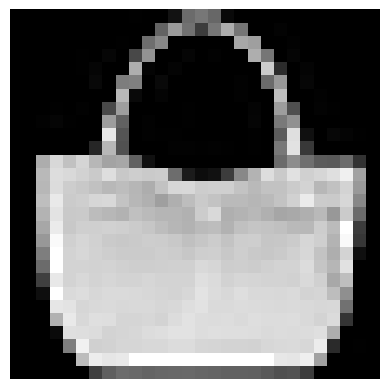

In [6]:
# 실제 이미지 확인
plt.imshow(X_train[100], cmap='gray')  # cmap='gray' : 흑백으로 출력
plt.axis('off')                        # x축, y축 눈금을 표시하지 않도록 설정
plt.show()


In [7]:
# 정답 확인 - 위에서 본 이미지가 몇 번 클래스인지 확인
# (위 분류표와 대조해보기 → 8 = 가방)
y_train[100]


np.uint8(8)

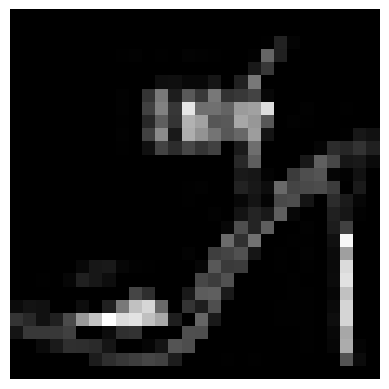

In [8]:
# 다른 이미지도 확인해보기
plt.imshow(X_train[1180], cmap='gray')
plt.axis('off')
plt.show()


In [9]:
# 정답 확인 (→ 5 = 샌들)
y_train[1180]


np.uint8(5)

### 3-2. 여러가지 이미지 확인 및 정답과 비교

- 위처럼 `plt.imshow()` + `y_train[]` 조합으로 **이미지와 정답이 맞는지 직접 눈으로 검증**한다
- 데이터를 학습시키기 전에 "내가 다루는 데이터가 무엇인지" 확인하는 습관이 중요하다


## 4. 신경망 설계 시 주의할 점 ⚠️

**1) 다차원 → 1차원 변환 필요**
- MLP층에서 `Dense`층을 사용할 때는 다차원 데이터를 쓸 수 없으므로 1차원으로 변경해야 한다
  - `reshape()`를 이용해 직접 데이터를 변경하는 방법
  - `Flatten` 층을 활용해 자동으로 1차원으로 변경하는 방법 👍

**2) 다중분류이므로 출력층 구조 주의**
- `units` : 정답의 종류만큼 → **10개**
- `activation` : **`softmax`** 사용
- softmax는 10개의 확률값을 출력하므로, 정수 1개인 기존 정답 데이터도 같은 형태로 바꿔야 한다
  → **원핫인코딩 진행**


### 4-1. softmax를 사용하므로 정답 데이터 원핫인코딩 진행

```
정답 8  →  [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
```
예측값(확률 10개)과 정답의 **모양(shape)을 맞춰주기 위한 작업**이다.


In [10]:
# 정답 데이터 원핫인코딩 진행
# pd.get_dummies() : 클래스마다 열을 만들어 해당 위치만 1, 나머지는 0
# dtype=int : True/False가 아닌 1/0 으로 저장
y_train_one_hot = pd.get_dummies(y_train, dtype=int)  # (60000,) → (60000, 10)
y_test_one_hot  = pd.get_dummies(y_test,  dtype=int)  # (10000,) → (10000, 10)


In [11]:
# 원핫인코딩이 잘 되어있는지 확인
# 각 행마다 1이 딱 한 개만 있으면 정상
y_train_one_hot.head()


,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0


In [12]:
# 픽셀값 정규화 (0~255 → 0~1)
# 신경망은 입력값이 작을수록(0~1) 학습이 안정적이다.
# ※ 이 셀을 두 번 실행하면 255로 두 번 나눠지므로, 원본 데이터부터 다시 불러온다
# ※ 3가지 조합을 공정하게 비교하려면 모델을 만들기 "전에" 다 같이 정규화해두어야 한다
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(X_train.min(), X_train.max())   # 0.0 1.0 이 나오면 정상

0.0 1.0


## 5. 신경망 설계 진행 (여러가지 조합 비교)

- 여러 가지 **활성화 함수 + 최적화 함수** 조합으로 신경망을 설계한 후 성능을 비교한다
- **층 구조(units 64-128-64) / epochs(30) / 배치 크기(기본 32) 를 모두 고정**하고
  조합만 바꿔야 공정한 비교가 된다

| 조합 | activation | optimizer |
|:---:|---|---|
| 1번 | sigmoid | SGD |
| 2번 | sigmoid | adam |
| 3번 | relu | adam |

> 결과는 각 셀을 실행한 뒤 아래 "오늘의 정리"에서 비교한다.

In [13]:
# 신경망 설계를 위한 도구 불러오기
from tensorflow.keras.models import Sequential   # 뼈대 생성을 도와주는 도구
from tensorflow.keras.layers import InputLayer   # 입력층을 쌓는 도구 중 하나
from tensorflow.keras.layers import Dense        # 중간층과 출력층을 쌓을 때 사용하는 도구
from tensorflow.keras.layers import Flatten      # 다차원 데이터를 1차원 데이터로 펴주는 도구


### 5-1. 1번 조합 : `activation = sigmoid` / `optimizer = SGD`

가장 기본이 되는 조합. **다른 조합과 비교할 기준점(baseline)** 으로 삼는다.


In [14]:
# ===== 1번 조합 : sigmoid + SGD =====
# 1. 뼈대 생성
model1 = Sequential()

# 2. 입력층 쌓기
# 입력할 데이터 1개의 형태 입력 - (28, 28)
model1.add(InputLayer(shape = (28, 28)))
model1.add(Flatten())   # Dense층을 쓰기 위해 1차원으로 변경 (28,28) → (784,)

# 3. 중간층 쌓기 - 3개의 층 / units → 64, 128, 64 / activation → sigmoid
model1.add(Dense(64,  activation = 'sigmoid'))
model1.add(Dense(128, activation = 'sigmoid'))
model1.add(Dense(64,  activation = 'sigmoid'))

# 4. 출력층 - units는 정답의 종류(10개) / 다중분류이므로 softmax
model1.add(Dense(units = 10, activation = 'softmax'))

# 5. 학습방법 설정 (compile)
model1.compile(
    optimizer = 'SGD',                    # 최적화 함수 → SGD (방향 보정 X, 지그재그 발생)
    loss = 'categorical_crossentropy',    # 다중분류용 손실함수
    metrics = ['accuracy'])               # 평가지표 → 정확도

# 6. 학습 - 세 조합 모두 epochs=30 / 배치 크기 기본값(32) 으로 동일 (공정한 비교)
#    X_train 은 위에서 이미 /255.0 정규화했으므로 여기서 또 나누지 않는다
#    verbose = 2 : epoch 당 한 줄만 출력 (주피터에서 진행바가 깨지지 않는다)
model1.fit(
    X_train, y_train_one_hot,
    epochs = 30,
    validation_data = (X_test, y_test_one_hot),
    verbose = 2)

Epoch 1/30
1875/1875 - 2s - 863us/step - accuracy: 0.1199 - loss: 2.2981 - val_accuracy: 0.1936 - val_loss: 2.2858
Epoch 2/30
1875/1875 - 1s - 534us/step - accuracy: 0.2276 - loss: 2.2575 - val_accuracy: 0.3837 - val_loss: 2.2063
Epoch 3/30
1875/1875 - 1s - 602us/step - accuracy: 0.3265 - loss: 2.0188 - val_accuracy: 0.4063 - val_loss: 1.7823
Epoch 4/30
1875/1875 - 2s - 805us/step - accuracy: 0.4380 - loss: 1.6367 - val_accuracy: 0.4722 - val_loss: 1.5170
Epoch 5/30
1875/1875 - 1s - 656us/step - accuracy: 0.5284 - loss: 1.4084 - val_accuracy: 0.5718 - val_loss: 1.3150
Epoch 6/30
1875/1875 - 1s - 664us/step - accuracy: 0.5875 - loss: 1.2289 - val_accuracy: 0.5991 - val_loss: 1.1603
Epoch 7/30
1875/1875 - 1s - 562us/step - accuracy: 0.6144 - loss: 1.0906 - val_accuracy: 0.6137 - val_loss: 1.0423
Epoch 8/30
1875/1875 - 1s - 697us/step - accuracy: 0.6461 - loss: 0.9878 - val_accuracy: 0.6585 - val_loss: 0.9540
Epoch 9/30
1875/1875 - 1s - 559us/step - accuracy: 0.6776 - loss: 0.9091 - val_a

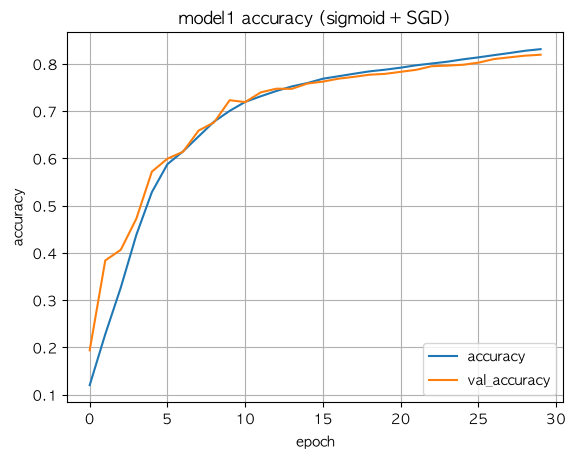

In [15]:
# 1번 조합(sigmoid + SGD) 학습 결과 시각화
# model1.history.history : fit을 따로 변수에 담지 않아도 모델 안에 학습기록이 남는다
plt.plot(model1.history.history['accuracy'],     label = 'accuracy')      # 훈련 정확도
plt.plot(model1.history.history['val_accuracy'], label = 'val_accuracy')  # 검증 정확도
plt.grid(True)                    # 격자 표시
plt.title('model1 accuracy (sigmoid + SGD)')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc = 'lower right')   # 범례를 오른쪽 아래에 배치
plt.show()

# [보는 법]
# 두 선이 붙어서 상승 → 아직 과대적합 아님, 더 학습하거나 조합을 바꿔볼 여지가 있다
# acc↑ / val_acc↓ 로 벌어지면 → 과대적합(Overfitting)

### 1번 조합 결과 정리

- **1번 조합(sigmoid + SGD)** 은 30 epoch을 다 돌려도 정확도가 천천히 올라간다
- SGD는 이전에 움직이던 방향을 참고하지 않아 **지그재그로 내려가기 때문에 느리다**
- 여기서부터 **optimizer를 바꾸면(2번)**, **activation을 바꾸면(3번)**
  얼마나 좋아지는지 하나씩 비교해본다

> ⚠️ SGD는 배치 크기에 특히 민감하다. `batch_size`를 256처럼 크게 잡으면
> 가중치 업데이트 횟수가 1/8로 줄어서 정확도가 0.5 아래로 떨어진다.
> 그래서 세 조합 모두 **기본 배치 크기(32)** 를 그대로 사용한다.

## 2번째 조합
- activation : sigmoid / optimizer :adam


In [16]:
# ===== 2번 조합 : sigmoid + adam =====
# 1. 뼈대 생성
model2 = Sequential()

# 2. 입력층 쌓기
model2.add(InputLayer(shape = (28, 28)))
model2.add(Flatten())

# 3. 중간층 쌓기 (위와 동일하게 3개층으로 쌓기)
model2.add(Dense(64,  activation = 'sigmoid'))
model2.add(Dense(128, activation = 'sigmoid'))
model2.add(Dense(64,  activation = 'sigmoid'))

# 4. 출력층 쌓기 - 다중분류이므로 softmax
model2.add(Dense(units = 10, activation = 'softmax'))

# 5. 학습방법 설정 (compile)
model2.compile(
    optimizer = 'adam',                   # 최적화 함수 → Adam (방향 + 학습률 동시 보정)
    loss = 'categorical_crossentropy',    # 다중분류용 손실함수
    metrics = ['accuracy'])               # 평가지표 → 정확도

# 6. 학습 - 1번 조합과 완전히 동일한 조건으로 (공정한 비교)
model2.fit(
    X_train, y_train_one_hot,
    epochs = 30,
    validation_data = (X_test, y_test_one_hot),
    verbose = 2)

Epoch 1/30
1875/1875 - 2s - 959us/step - accuracy: 0.7444 - loss: 0.7383 - val_accuracy: 0.8282 - val_loss: 0.4821
Epoch 2/30
1875/1875 - 1s - 660us/step - accuracy: 0.8499 - loss: 0.4183 - val_accuracy: 0.8507 - val_loss: 0.4268
Epoch 3/30
1875/1875 - 1s - 656us/step - accuracy: 0.8667 - loss: 0.3711 - val_accuracy: 0.8537 - val_loss: 0.4102
Epoch 4/30
1875/1875 - 1s - 659us/step - accuracy: 0.8757 - loss: 0.3478 - val_accuracy: 0.8630 - val_loss: 0.3844
Epoch 5/30
1875/1875 - 1s - 648us/step - accuracy: 0.8811 - loss: 0.3288 - val_accuracy: 0.8651 - val_loss: 0.3745
Epoch 6/30
1875/1875 - 1s - 642us/step - accuracy: 0.8871 - loss: 0.3128 - val_accuracy: 0.8589 - val_loss: 0.3873
Epoch 7/30
1875/1875 - 1s - 645us/step - accuracy: 0.8902 - loss: 0.3018 - val_accuracy: 0.8665 - val_loss: 0.3794
Epoch 8/30
1875/1875 - 1s - 665us/step - accuracy: 0.8945 - loss: 0.2930 - val_accuracy: 0.8742 - val_loss: 0.3586
Epoch 9/30
1875/1875 - 1s - 633us/step - accuracy: 0.8973 - loss: 0.2820 - val_a

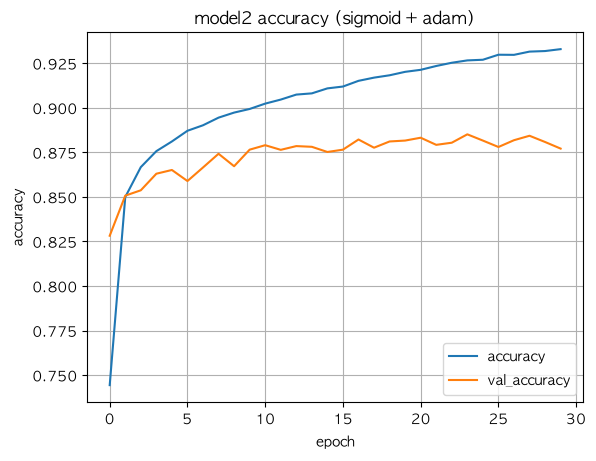

In [17]:
# 2번 조합(sigmoid + adam) 학습 결과 시각화
# model2.history.history : fit을 따로 변수에 담지 않아도 모델 안에 학습기록이 남는다
plt.plot(model2.history.history['accuracy'],     label = 'accuracy')      # 훈련 정확도
plt.plot(model2.history.history['val_accuracy'], label = 'val_accuracy')  # 검증 정확도
plt.grid(True)                    # 격자 표시
plt.title('model2 accuracy (sigmoid + adam)')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc = 'lower right')   # 범례를 오른쪽 아래에 배치
plt.show()

# [보는 법]
# 두 선이 붙어서 같이 상승 → 아직 과대적합 아님, 더 학습해볼 여지가 있다
# acc↑ / val_acc↓ 로 벌어지면 → 과대적합(Overfitting)

## 3번째 조합
- activation : **relu** / optimizer : **adam**

`sigmoid`는 층이 깊어질수록 기울기가 0에 가까워져 학습이 잘 안 되는
**기울기 소실(Vanishing Gradient)** 문제가 있다.
`relu`는 양수 구간에서 기울기가 항상 1이라 이 문제가 완화된다.

> 2번 조합과 **층 구조 / epochs / batch_size 를 똑같이 두고 activation만** 바꿔야
> 성능 차이가 relu 덕분인지 정확히 알 수 있다.

In [18]:
# ===== 3번 조합 : relu + adam =====
# 1. 뼈대 생성
model3 = Sequential()

# 2. 입력층 쌓기
model3.add(InputLayer(shape = (28, 28)))
model3.add(Flatten())

# 3. 중간층 쌓기 (구조는 2번과 동일 / activation만 relu 로 변경)
model3.add(Dense(64,  activation = 'relu'))
model3.add(Dense(128, activation = 'relu'))
model3.add(Dense(64,  activation = 'relu'))

# 4. 출력층 쌓기 - 다중분류이므로 softmax (중간층이 relu여도 출력층은 softmax)
model3.add(Dense(units = 10, activation = 'softmax'))

# 5. 학습방법 설정 (compile)
model3.compile(
    optimizer = 'adam',                   # 최적화 함수 → Adam
    loss = 'categorical_crossentropy',    # 다중분류용 손실함수
    metrics = ['accuracy'])               # 평가지표 → 정확도

# 6. 학습 - 1번/2번 조합과 완전히 동일한 조건으로 (공정한 비교)
model3.fit(
    X_train, y_train_one_hot,
    epochs = 30,
    validation_data = (X_test, y_test_one_hot),
    verbose = 2)

Epoch 1/30
1875/1875 - 2s - 963us/step - accuracy: 0.8188 - loss: 0.5081 - val_accuracy: 0.8371 - val_loss: 0.4427
Epoch 2/30
1875/1875 - 1s - 600us/step - accuracy: 0.8630 - loss: 0.3732 - val_accuracy: 0.8654 - val_loss: 0.3951
Epoch 3/30
1875/1875 - 1s - 593us/step - accuracy: 0.8768 - loss: 0.3377 - val_accuracy: 0.8601 - val_loss: 0.3864
Epoch 4/30
1875/1875 - 1s - 599us/step - accuracy: 0.8828 - loss: 0.3191 - val_accuracy: 0.8753 - val_loss: 0.3534
Epoch 5/30
1875/1875 - 1s - 610us/step - accuracy: 0.8880 - loss: 0.2992 - val_accuracy: 0.8751 - val_loss: 0.3542
Epoch 6/30
1875/1875 - 1s - 597us/step - accuracy: 0.8938 - loss: 0.2852 - val_accuracy: 0.8753 - val_loss: 0.3516
Epoch 7/30
1875/1875 - 1s - 603us/step - accuracy: 0.8970 - loss: 0.2733 - val_accuracy: 0.8785 - val_loss: 0.3533
Epoch 8/30
1875/1875 - 1s - 672us/step - accuracy: 0.9002 - loss: 0.2638 - val_accuracy: 0.8810 - val_loss: 0.3384
Epoch 9/30
1875/1875 - 1s - 612us/step - accuracy: 0.9026 - loss: 0.2567 - val_a

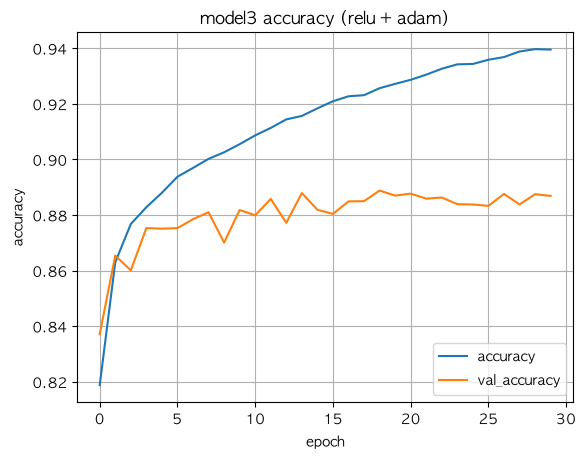

In [19]:
# 3번 조합(relu + adam) 학습 결과 시각화
plt.plot(model3.history.history['accuracy'],     label = 'accuracy')
plt.plot(model3.history.history['val_accuracy'], label = 'val_accuracy')
plt.grid(True)
plt.title('model3 accuracy (relu + adam)')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc = 'lower right')
plt.show()

### 정리
- 3가지 조합중에 relu + adam조합이 가장 성능이 높았다.
- sigmoid에 비해서 relu는 기울기 손실이 덜 일어나기 때문에 학습을 했을 때 성능적인 측면에서 유리할 가능성이 높다.
- 또한 adam은 최적화 함수중에서 장점들을 모아서 나온 함수이기 때문에 오차를 줄일 때 유리하게 적용될 가능성이 높아 성능이 높을 가능성이 있다.
- 모델을 사용할 때 relu 와 adam조합이 무조건 좋다라고 말할 수는 없지만 모델을 학습할 때 우선적으로 사용하면 성능에 대해 어느정도 기대할 수 있을 것으로 판단이 된다.

### 3가지 모델 성능을 비교해보기


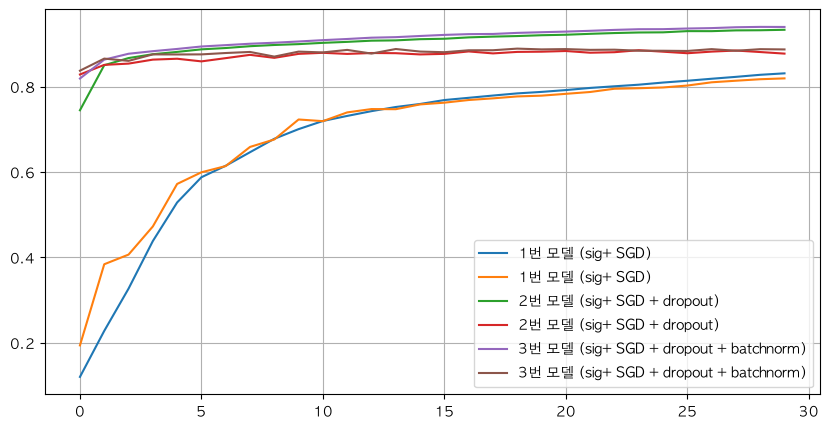

In [20]:
plt.figure(figsize=(10,5))

# 1번 모델 (sig+ SGD)
plt.plot(model1.history.history['accuracy'], label = '1번 모델 (sig+ SGD)')
plt.plot(model1.history.history['val_accuracy'], label = '1번 모델 (sig+ SGD)')

# 2번 모델 (sig+ SGD + dropout)
plt.plot(model2.history.history['accuracy'], label = '2번 모델 (sig+ SGD + dropout)')
plt.plot(model2.history.history['val_accuracy'], label = '2번 모델 (sig+ SGD + dropout)')

# 3번 모델 (sig+ SGD + dropout + batchnorm)
plt.plot(model3.history.history['accuracy'], label = '3번 모델 (sig+ SGD + dropout + batchnorm)')
plt.plot(model3.history.history['val_accuracy'], label = '3번 모델 (sig+ SGD + dropout + batchnorm)')

plt.grid(True)
plt.legend()
plt.show()

## 6. 얼리스탑핑 (Early Stopping) - 조기 학습 중단

- 모델의 성능이 **더 이상 좋아지지 않는 구간까지 계속 학습하는 것은 시간·자원 낭비**이다
- 개선이 멈췄다고 판단되면, 내가 설정한 `epochs`를 전부 돌지 않고 **중간에 학습을 멈추는 기능**
- 효과
  1. 불필요한 학습을 줄여 **자원(시간) 절약**
  2. 성능이 꺾인 뒤에도 계속 학습하면 생기는 **과대적합(Overfitting) 방지**

> 그래서 `epochs`는 일부러 **크게(100)** 잡아두고, "언제 멈출지는 EarlyStopping이 정하게" 하는 방식으로 쓴다.

### 주요 옵션
| 옵션 | 의미 |
|---|---|
| `monitor` | 개선 여부를 판단할 **기준 지표** (`val_accuracy`, `val_loss` 등) |
| `patience` | **몇 번의 epoch 동안** 개선이 없으면 멈출지 (참을성) |
| `restore_best_weights` | `True`면 멈춘 뒤 **가장 성능이 좋았던 시점의 가중치로 되돌린다** |

> ⚠️ `monitor`는 훈련 지표(`accuracy`)가 아니라 **검증 지표(`val_`)** 를 봐야 한다.
> 훈련 정확도는 과대적합 중에도 계속 올라가기 때문에 멈춰야 할 시점을 알려주지 못한다.

In [21]:
# 조기 학습 중단(EarlyStopping) 도구 불러오기
# callbacks : 학습(fit)이 진행되는 "도중에" 끼어들어 동작하는 기능들의 모음
from tensorflow.keras.callbacks import EarlyStopping

In [32]:
# 조기 학습 중단 설정하기
model_earlystop = EarlyStopping(
    monitor = 'val_accuracy',     # 기준점 : 검증 정확도가 개선되는지를 보고 판단
    patience = 5,                 # 5번의 epoch 동안 개선이 없으면 학습 중단
    restore_best_weights = True   # 중단 후 가장 좋았던 시점의 가중치로 되돌리기
)

# [옵션 설명]
# monitor              : 개선이 됐는지 안 됐는지를 판단하기 위한 지표 설정
# patience             : 몇 번 학습하는 동안 개선이 안 될 시 조기종료를 할지 설정
# restore_best_weights : 기본값은 False → 그냥 두면 "마지막 epoch"의 가중치가 남는다.
#                        마지막은 이미 성능이 꺾인 지점이므로 True로 두는 것이 좋다.

# ※ mode 옵션은 기본값 'auto' → monitor 이름에 'accuracy'가 있으면 "클수록 좋음",
#    'loss'가 있으면 "작을수록 좋음"으로 알아서 판단해준다.

In [23]:
# EarlyStopping을 적용하기 위해 신경망 설계를 다시 진행
# 구조는 3번 조합(relu + adam)과 동일하게 두고, "학습을 멈추는 기능"만 추가로 확인한다

# 뼈대 생성
model4 = Sequential()

# 입력층 쌓기
model4.add(InputLayer(shape=(28, 28, )))
model4.add(Flatten())              # 2차원(28x28) → 1차원(784)로 펴주기
# 중간층 쌓기
model4.add(Dense(units=64, activation='relu'))
model4.add(Dense(units=128, activation='relu'))
model4.add(Dense(units=64, activation='relu'))
# 출력층 쌓기 - 다중분류이므로 units=10, softmax
model4.add(Dense(units=10, activation='softmax'))

# 학습방법 및 평가방법 설정
model4.compile(
    loss = 'categorical_crossentropy',   # 다중분류 + 원핫인코딩된 정답 → categorical
    optimizer = 'adam',
    metrics = ['accuracy']
)

# 학습 진행
model4.fit(
    X_train, y_train_one_hot,
    epochs = 100,                      # 일부러 크게 설정 → 멈추는 시점은 EarlyStopping이 결정
    validation_split = 0.2,            # 훈련데이터의 20%를 검증용으로 자동 분리 (48000 / 12000)
    callbacks = [model_earlystop]      # ★ 여기에 넣어줘야 조기중단이 실제로 동작한다
)

# [결과] 100번을 다 돌지 않고 30 epoch에서 자동 종료됨
#        → 25번째 epoch(val_accuracy 0.8928)를 마지막으로 5번 동안 개선이 없었기 때문

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 802us/step - accuracy: 0.8098 - loss: 0.5314 - val_accuracy: 0.8466 - val_loss: 0.4307
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step - accuracy: 0.8596 - loss: 0.3824 - val_accuracy: 0.8660 - val_loss: 0.3713
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 670us/step - accuracy: 0.8732 - loss: 0.3455 - val_accuracy: 0.8772 - val_loss: 0.3393
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step - accuracy: 0.8795 - loss: 0.3218 - val_accuracy: 0.8678 - val_loss: 0.3583
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 672us/step - accuracy: 0.8848 - loss: 0.3071 - val_accuracy: 0.8792 - val_loss: 0.3418
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 729us/step - accuracy: 0.8929 - loss: 0.2874 - val_accuracy: 0.8790 - val_loss: 0.3320
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 739us/step - accuracy: 0.8961 - loss: 0.2772 - val_accuracy: 0.8775 - val_loss: 0.3385
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 650us/step - accuracy: 

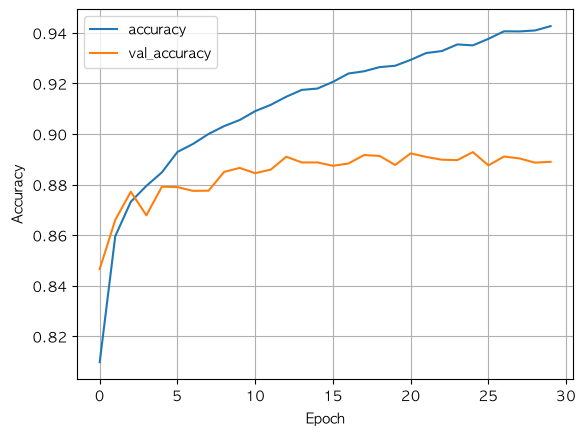

In [24]:
# EarlyStopping이 적용된 model4의 학습 곡선 확인
plt.plot(model4.history.history['accuracy'])
plt.plot(model4.history.history['val_accuracy'])

plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['accuracy', 'val_accuracy'], loc='upper left')
plt.show()

# [보는 법]
# 훈련 정확도(accuracy)는 계속 올라가는데 검증 정확도(val_accuracy)는 평평해지는 지점
#   → 여기서부터는 "외우기(과대적합)"만 하고 있는 구간
# EarlyStopping은 바로 이 지점을 감지해서 학습을 멈춰준 것이다

## 7. 학습한 모델을 저장하는 방법 (ModelCheckpoint)

- 학습이 끝나고 나면 모델은 **메모리에만** 존재한다 → 커널을 껐다 켜면 사라진다
- 학습 도중 **성능이 가장 좋았던 지점의 모델을 파일로 저장**해두면,
  나중에 다시 학습하지 않고 **불러와서 바로 예측에 사용**할 수 있다

### 주요 옵션
| 옵션 | 의미 |
|---|---|
| `filepath` | 저장할 경로와 파일명 (확장자 `.keras`) |
| `monitor` | 무엇을 기준으로 "좋은 모델"인지 판단할 지표 |
| `save_best_only` | `True`면 **기록을 갱신했을 때만** 덮어쓴다 (매 epoch마다 저장 X) |

> ⚠️ `filepath`에 적은 **폴더(`./model/`)가 미리 존재해야** 한다. 없으면 에러가 발생한다.

### EarlyStopping vs ModelCheckpoint
| | 역할 |
|---|---|
| **EarlyStopping** | 학습을 **언제 멈출지** 결정 |
| **ModelCheckpoint** | 가장 좋은 모델을 **파일로 남기는** 역할 |

> 둘은 하는 일이 다르므로 **같이 사용**하는 것이 일반적이다.

In [25]:
# 학습할 때 모델을 저장할 수 있도록 도와주는 도구 불러오기
# ModelCheckpoint 도 EarlyStopping 과 같은 callbacks(학습 도중에 동작하는 기능) 중 하나
from tensorflow.keras.callbacks import ModelCheckpoint

In [33]:
# 모델 저장 설정 (checkpoint 설정)
checkpoint = ModelCheckpoint(
    filepath = './model/best_model.keras',   # 저장 경로 (model 폴더가 미리 있어야 함!)
    monitor = 'val_accuracy',                # 검증 정확도를 기준으로 좋은 모델인지 판단
    save_best_only = True                    # 기록을 갱신했을 때만 저장 (덮어쓰기)
)

# [옵션 설명]
# filepath       : 확장자를 .keras 로 지정 (Keras 3의 기본 저장 형식 / 모델 구조 + 가중치가 모두 저장됨)
# save_best_only : False로 두면 매 epoch마다 저장해서 파일이 계속 덮어써진다 → True 권장

# ※ 폴더가 없을 때 자동 생성하고 싶다면
#    import os
#    os.makedirs('./model', exist_ok=True)

In [34]:
# 위에서 설정한 저장방법(checkpoint)을 활용하여 모델 저장 진행
# 학습할 때 조기중단(EarlyStopping) 설정까지 같이 진행
# 신경망 설계 진행

model5 = Sequential()

# 입력층 쌓기
model5.add(InputLayer(shape=(28, 28, )))
model5.add(Flatten())
# 중간층 쌓기
model5.add(Dense(units=64, activation='relu'))
model5.add(Dense(units=128, activation='relu'))
model5.add(Dense(units=64, activation='relu'))
# 출력층 쌓기
model5.add(Dense(units=10, activation='softmax'))

# 학습방법 및 평가방법 설정
model5.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

# 학습 진행
model5.fit(
    X_train, y_train_one_hot,
    epochs = 100,
    validation_split = 0.2,
    callbacks = [model_earlystop, checkpoint]   # ★ 콜백은 리스트로 여러 개 동시에 넣을 수 있다
)

# ⚠️ callbacks 철자 주의! (callbaacks 처럼 오타를 내면 TypeError 발생)

# [결과] 19 epoch에서 조기 종료 (최고 기록은 14번째 epoch, val_accuracy 0.8917)
#        → ./model/best_model.keras 파일에 14번째 시점의 모델이 저장되어 있다

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 740us/step - accuracy: 0.8082 - loss: 0.5359 - val_accuracy: 0.8547 - val_loss: 0.4100
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 672us/step - accuracy: 0.8598 - loss: 0.3849 - val_accuracy: 0.8708 - val_loss: 0.3574
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step - accuracy: 0.8725 - loss: 0.3463 - val_accuracy: 0.8654 - val_loss: 0.3661
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step - accuracy: 0.8815 - loss: 0.3225 - val_accuracy: 0.8760 - val_loss: 0.3425
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 700us/step - accuracy: 0.8875 - loss: 0.3045 - val_accuracy: 0.8779 - val_loss: 0.3440
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 669us/step - accuracy: 0.8920 - loss: 0.2893 - val_accuracy: 0.8720 - val_loss: 0.3533
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 675us/step - accuracy: 0.8973 - loss: 0.2772 - val_accuracy: 0.8823 - val_loss: 0.3295
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - accuracy: 

### 7-1. 저장한 모델 불러와서 사용하기

- 저장해둔 `.keras` 파일에는 **모델 구조 + 가중치 + compile 설정**이 모두 들어있다
- 따라서 불러오기만 하면 **다시 설계하거나 학습할 필요 없이 바로 평가/예측**이 가능하다

In [ ]:
# 저장한 모델 불러오기
from tensorflow.keras.models import load_model

best_model = load_model('./model/best_model.keras')

# 테스트 데이터로 최종 성능 평가
# ※ 지금까지 본 val_accuracy는 "훈련데이터에서 떼어낸 검증용" 점수이고,
#    아래는 한 번도 학습에 사용되지 않은 진짜 테스트 데이터의 점수이다
loss, acc = best_model.evaluate(X_test, y_test_one_hot)
print('테스트 정확도 :', acc)

## 8. 배치 사이즈 (batch_size)

- **한 번에 몇 장씩 보고 공부할지**를 정하는 값 (기본값 : 32)
- 모델은 데이터를 한 장씩 보는 것도, 6만 장을 한꺼번에 보는 것도 아니고
  **정해진 묶음(batch) 단위로 나눠서** 보고 → 그때마다 가중치를 조금씩 수정한다

> 📚 시험공부에 비유하면
> - 문제집 **6만 문제**를 처음부터 끝까지 1바퀴 = **1 epoch**
> - **32문제씩 풀고 답을 맞춰보는 것** = **batch_size = 32**
> - 32문제마다 채점하면서 "아, 이건 이렇게 푸는구나" 하고 고쳐나가는 것 = **가중치 업데이트**

### 학습 로그에 찍히는 숫자의 정체
```
1500/1500 ━━━━━━━━━━ 1s - accuracy: 0.9426
```
- 훈련 데이터 60000장 중 20%(`validation_split=0.2`)를 검증용으로 빼면 → **48000장**
- 48000 ÷ 32 = **1500** → 즉 **1 epoch 안에서 가중치를 1500번 수정**했다는 뜻

### 배치 사이즈를 바꾸면?
| | 배치 작게 (예: 8) | 배치 크게 (예: 512) |
|---|---|---|
| 업데이트 횟수 | 많다 | 적다 |
| 학습 속도 | 느리다 | 빠르다 |
| 메모리 사용 | 적다 | 많다 |
| 특징 | 꼼꼼하지만 들쭉날쭉 | 안정적이지만 대충 넘어갈 수 있음 |

```python
model.fit(X_train, y_train_one_hot,
          epochs = 30,
          batch_size = 32)   # 생략하면 자동으로 32
```

> 💡 정리하면
> - `epochs` = **문제집을 몇 바퀴 돌지**
> - `batch_size` = **몇 문제씩 끊어서 채점할지**
>
> 보통 32 / 64 / 128 처럼 **2의 배수**를 쓰고, 특별한 이유가 없으면 **기본값 32로 시작**하면 된다.
> ⚠️ 조합별 성능을 비교할 때는 `batch_size`도 **똑같이 고정**해야 공정한 비교가 된다.

## 9. 오늘의 정리 ⭐

### 조합별 성능 비교 (epochs 30 고정)
| 조합 | activation | optimizer | 훈련 정확도 | 검증 정확도 |
|:---:|---|---|:---:|:---:|
| 1번 | sigmoid | SGD | 0.8309 | 0.8191 |
| 2번 | sigmoid | adam | 0.9329 | 0.8771 |
| **3번** | **relu** | **adam** | **0.9395** | **0.8869** ⭐ |

- **relu + adam** 조합의 성능이 가장 높았다
- `sigmoid`는 층이 깊어질수록 **기울기 소실(Vanishing Gradient)** 이 일어나 학습이 잘 안 된다.
  `relu`는 양수 구간의 기울기가 항상 1이라 이 문제가 완화된다.
- `adam`은 **방향(Momentum) + 학습률 조절(Adagrad)** 의 장점을 합친 최적화 함수라 오차를 줄이는 데 유리하다.

> 단, "relu + adam이 무조건 정답"은 아니다. **데이터마다 최적 조합은 다르므로 직접 비교**해야 한다.
> 다만 **처음 시작할 때 기준점(baseline)으로 잡기 좋은 조합**이라고 이해하면 된다.

### 콜백(callbacks) 정리
| 기능 | 역할 | 핵심 옵션 |
|---|---|---|
| `EarlyStopping` | 개선이 멈추면 학습을 **중단** | `monitor`, `patience`, `restore_best_weights` |
| `ModelCheckpoint` | 가장 좋은 모델을 **파일로 저장** | `filepath`, `monitor`, `save_best_only` |

```python
model.fit(..., epochs=100, validation_split=0.2,
          callbacks=[model_earlystop, checkpoint])
```

- `epochs`는 **크게 잡아두고**, 멈추는 시점은 EarlyStopping에게 맡기는 방식이 일반적이다
- 두 콜백은 역할이 다르므로 **함께 사용**한다

### 실습 결과
| 모델 | 설정 | 종료 epoch | 최고 검증 정확도 |
|:---:|---|:---:|:---:|
| model4 | EarlyStopping | 30 / 100 | 0.8928 |
| model5 | EarlyStopping + Checkpoint | 19 / 100 | 0.8917 |

- 100번을 다 돌지 않고 자동으로 멈춰 **학습 시간을 크게 절약**했다
- 성능은 30 epoch를 다 돌린 3번 조합과 거의 차이가 없다 → **뒷부분 학습은 낭비였다**는 뜻

### 오늘 실수했던 부분 ✍️
- `callbacks`를 `callbaacks`로 오타 → 콜백이 등록되지 않아 조기중단/저장이 동작하지 않는다 (`TypeError`)
- `restore_best_weights`를 빼먹으면 **마지막(성능이 꺾인) 시점의 가중치**가 남는다
- `ModelCheckpoint`의 저장 폴더(`./model/`)는 **미리 만들어두어야** 한다